In [1]:
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached numpy-2.4.4-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/2.6 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 GB 12.2 MB/s eta 0:03:35
   ---------------------------------------- 0.0/2.6 GB 12.1 MB/s eta 0:03:37
   ---------------------------------------- 0.0/2.6 GB 12.0 MB/s eta 0:03:39
   ---------------------------------------- 0.0/2.6 GB 11.0 MB/s eta 0:03:59
   ---------------------------------------- 0.0/2.6 GB 11.4 MB/s eta 0:03:50
   -------------------


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install -U sentence-transformers

  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/588.9 kB ? eta -:--:--
   ---------------------------------------- 588.9/588.9 kB 7.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/10.8 MB ? eta -:--:--
   ------- -------------------------------- 2.1/10.8 MB 10.7 MB/s eta 0:00:01
   ---------------- -------------


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

model_name = "sentence-transformers/all-mpnet-base-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

def get_embedding(text):
    # 1. Tokenize
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)

    with torch.no_grad():
        outputs = model(**inputs)

    # 2. Mean Pooling - Take attention mask into account (ignores padding)
    attention_mask = inputs['attention_mask']
    token_embeddings = outputs.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    embedding = torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

    # 3. Normalize embeddings (Crucial for MPNet)
    return F.normalize(embedding, p=2, dim=1)

# Usage
orig_vec = get_embedding("and he is 23 year old and he can learn .")
paraphrase_vec = get_embedding(" shit")

# Calculate similarities
cosine_sim  = torch.mm(orig_vec, paraphrase_vec.transpose(0, 1))
percent = cosine_sim .item() * 100

print(f"Paraphrase Score: {percent:.2f}%")

if percent < 30:
    print(f"RESULT: Original content.")
elif percent < 60:
    print(f"RESULT: Partial similarity")
else:
    print(f"RESULT: Copied")

C:\Users\vuong\PycharmProjects\Deep learning 2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4093.15it/s]


Paraphrase Score: 10.83%
RESULT: Original content.


In [1]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

model_name = "sentence-transformers/all-mpnet-base-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

def get_embeddings_batch(texts: list[str]):
    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    )

    with torch.no_grad():
        outputs = model(**inputs)

    attention_mask = inputs['attention_mask']
    token_embeddings = outputs.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    embeddings = torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

    return F.normalize(embeddings, p=2, dim=1)  # Shape: (N, 768)


#Compare one original against many candidates
texts = [
    "The quick brown fox jumps over the lazy dog.", #index 0 = original
    "A fast auburn fox leaps above the idle hound.", #Ground truth 1: paraphrase
    "She sells seashells by the seashore.",   #Ground truth 0: index unrelated
    "The quick brown fox jumps over the lazy dog.", #Ground truth 1: exact copy
]

embeddings = get_embeddings_batch(texts)

original = embeddings[0].unsqueeze(0)     #shape(1, 768)
candidates = embeddings[1:]               #shape(3, 768)

similarities = torch.mm(original, candidates.T).squeeze(0)  # shape (3,)

for i, score in enumerate(similarities):
    percent = score.item() * 100
    label = (
        "Likely copied"    if percent >= 80 else
        "Partial match"    if percent >= 50 else
        "Original content"
    )
    print(f"Candidate {i+1}: {percent:.2f}% -> {label}")

C:\Users\vuong\PycharmProjects\Deep learning 2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3905.38it/s]


Candidate 1: 77.75% -> Partial match
Candidate 2: -8.81% -> Original content
Candidate 3: 100.00% -> Likely copied


Model Evaluation Metrics
Accuracy: 100.00%

Detailed Report:
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00         1
       Match       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



C:\Users\vuong\AppData\Local\Temp\ipykernel_24556\3026460239.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=scores, palette=colors)


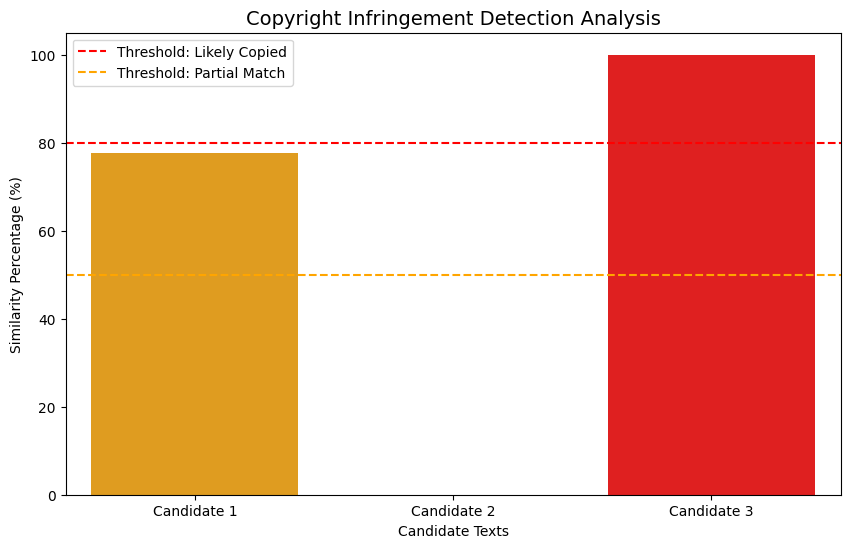

In [6]:
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

ground_truth = [1, 0, 1] # Labels for the candidates (excluding index 0)

# 2. Run your existing function
embeddings = get_embeddings_batch(texts)
original = embeddings[0].unsqueeze(0)
candidates = embeddings[1:]
similarities = torch.mm(original, candidates.T).squeeze(0)

# 3. Model Predictions based on your 50% threshold
predictions = []
for score in similarities:
    percent = score.item() * 100
    # If score >= 50, we predict it is a match (1), else safe (0)
    predictions.append(1 if percent >= 50 else 0)

# 4. Final Evaluation Metrics
print("Model Evaluation Metrics")
print(f"Accuracy: {accuracy_score(ground_truth, predictions) * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(ground_truth, predictions, target_names=["Safe", "Match"]))


def plot_similarities(labels, scores):
    plt.figure(figsize=(10, 6))

    # Define colors based on score
    colors = ['red' if s >= 80 else 'orange' if s >= 50 else 'green' for s in scores]

    sns.barplot(x=labels, y=scores, palette=colors)

    plt.axhline(y=80, color='red', linestyle='--', label='Threshold: Likely Copied')
    plt.axhline(y=50, color='orange', linestyle='--', label='Threshold: Partial Match')

    plt.title('Copyright Infringement Detection Analysis', fontsize=14)
    plt.ylabel('Similarity Percentage (%)')
    plt.xlabel('Candidate Texts')
    plt.ylim(0, 105)
    plt.legend()
    plt.show()

# Usage from your specific code
candidate_labels = [f"Candidate {i+1}" for i in range(len(similarities))]
scores_list = [s.item() * 100 for s in similarities]
plot_similarities(candidate_labels, scores_list)

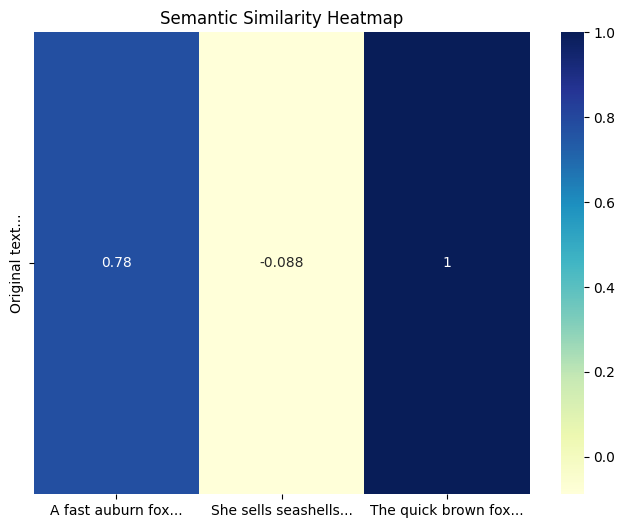

In [9]:
def plot_heatmap(original_text, candidate_texts, similarity_matrix):
    plt.figure(figsize=(8, 6))

    # Reshape similarity for the heatmap (1 row, N columns)
    data = similarity_matrix.cpu().numpy().reshape(1, -1)

    sns.heatmap(data, annot=True, cmap="YlGnBu", xticklabels=candidate_texts, yticklabels=[original_text[:20]+"..."])

    plt.title("Semantic Similarity Heatmap")
    plt.show()

# Usage
plot_heatmap("Original text", ["A fast auburn fox...", "She sells seashells...", "The quick brown fox..."], similarities)